# Métricas de Avaliação de Modelos

**Francisco A. Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nas aulas anteriores, aprendemos a avaliar um modelo de classificação usando a medida de acurácia e, no caso da regressão, o erro quadrático médio. No entanto, há outras métricas e gráficos que podemos usar para avaliar um modelo.

Nessa aula, veremos:
- matriz de confusão;
- acurácia, precision, recall, especificidade e F1;
- curvas ROC, AUC e Precision–Recall;
- na regressão: MAE, MSE, RMSE, $R^2$, $R^2$ ajustado.

Inicialmente, vamos carregar as bibliotecas necessárias.

In [1]:
#  Manipulação de dados
import numpy as np
import pandas as pd

# Visualização 
import matplotlib.pyplot as plt
import seaborn as sns

# Geração de dados sintéticos 
from sklearn.datasets import make_classification, make_regression

# Préprocessamento 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

# Modelos de classificação 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

# Modelos de regressão 
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Métricas de classificação 
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    classification_report
)

# Métricas de regressão 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

random_seed = 42  #  semente fixa, para resultados reproduzíveis

Vamos gerar um conjunto de dados sintético de classificação binária com `make_classification`. Escolhemos um nível de sobreposição moderado entre as classes (`class_sep`), para que o problema não seja trivial demais. Isso é importante para que as métricas realmente se diferenciem entre os modelos.

In [33]:
# Gera um conjunto de dados sintetico de classificacao binaria
X, y = make_classification(
    n_samples=1000,       # numero total de amostras
    n_features=10,        # numero total de atributos
    n_informative=6,       # numero de atributos realmente informativos (uteis para separar as classes)
    n_redundant=2,         # atributos redundantes (combinacoes lineares dos informativos)
    n_classes=2,           # problema de classificacao BINARIA
    weights=[0.5, 0.5],    # classes balanceadas (50%/50%) nesta primeira parte
    class_sep=0.9,          # grau de separacao entre as classes (menor valor = classes mais sobrepostas)
    random_state=random_seed
)

# Convertendo para DataFrame, apenas para facilitar a visualizacao
colunas = [f'atributo_{i+1}' for i in range(X.shape[1])]
df_class = pd.DataFrame(X, columns=colunas)
df_class['classe'] = y

print("Dimensões dos dados:", X.shape)
print("\nDistribuição das classes:")
print(df_class['classe'].value_counts())

df_class.head()

Dimensões dos dados: (1000, 10)

Distribuição das classes:
classe
1    502
0    498
Name: count, dtype: int64


,atributo_1,atributo_2,atributo_3,atributo_4,atributo_5,atributo_6,atributo_7,atributo_8,atributo_9,atributo_10,classe
0,-0.930931,1.291626,0.447274,0.928932,-1.638880,1.120229,1.332551,1.478256,1.941494,-0.218434,0
1,-2.666254,1.147870,-0.203691,1.083145,0.610836,1.998562,-1.794192,2.246422,1.708006,-0.101190,1
2,-0.458987,0.199849,1.427071,0.360442,-1.260209,0.971020,-0.755951,1.231933,1.857877,-0.724404,0
3,-1.250289,-1.946078,-0.514264,0.126459,-0.683923,5.579696,-0.915477,-3.084768,-0.416619,-3.820960,0
4,-0.175754,-0.628495,0.127727,-0.660834,-1.828161,3.229616,1.446944,-1.011662,0.296407,-2.276528,0


Dividindo em treinamento e teste.

In [3]:
# separa os conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed, stratify=y)

# Padronizamos os atributos (media 0, desvio 1)
# O scaler e ajustado (fit) apenas no treino, e depois aplicado (transform) tambem ao teste
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste: ", X_test.shape)

Tamanho do treino: (700, 10)
Tamanho do teste:  (300, 10)


Vamos treinar classificadores com hiperparâmetros fixos.

In [4]:
from sklearn.neighbors import KNeighborsClassifier
k = 41 # numero de vizinhos
# ajusta o modelo k-vizinhos
KNN = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
KNN.fit(X_train,y_train)
# faz a predição no conjunto de teste
y_pred_KNN = KNN.predict(X_test)

In [5]:
# Criamos uma árvore com profundidade máxima igual a max_depth.
Tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=5,
    random_state=random_seed
)

# O modelo aprende as regras usando apenas o conjunto de treinamento.
Tree.fit(X_train, y_train)
y_pred_tree = Tree.predict(X_test)

### Acurácia

A **acurácia** é a métrica mais intuitiva: mede a proporção de previsões
corretas (tanto positivas quanto negativas) em relação ao total de amostras.

$$
\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}
$$

onde:
- **VP** (Verdadeiro Positivo): o modelo previu "sobreviveu"/classe 1 e acertou;
- **VN** (Verdadeiro Negativo): o modelo previu "não sobreviveu"/classe 0 e acertou;
- **FP** (Falso Positivo): o modelo previu classe 1, mas a classe real era 0;
- **FN** (Falso Negativo): o modelo previu classe 0, mas a classe real era 1.

**Limitação importante:** em bases de dados **desbalanceadas**, a acurácia pode
ser enganosa. Por exemplo, se 95% dos exemplos pertencem à classe 0, um modelo
que sempre prevê "classe 0" (ignorando completamente a classe 1) já atinge 95%
de acurácia, mesmo sendo um modelo inútil. Veremos esse efeito na prática mais
adiante, na Seção 9.

In [6]:
acc_KNN = accuracy_score(y_test, y_pred_KNN)
print('Acurácia no K-NN:', acc_KNN)
acc_tree = accuracy_score(y_test, y_pred_tree)
print('Acurácia na Árvore de decisão:', acc_tree)

Acurácia no K-NN: 0.8666666666666667
Acurácia na Árvore de decisão: 0.8233333333333334


### Matriz de confusão

A **matriz de confusão** organiza, em uma tabela, a contagem de VP, VN,
FP e FN, permitindo enxergar não apenas *quantos* erros o modelo comete, mas
também *que tipo* de erro (falso positivo ou falso negativo) é mais frequente
— informação que a acurácia sozinha não revela.

Estrutura da matriz (para classificação binária):

|                     | Previsto: Classe 0 | Previsto: Classe 1 |
|---------------------|:-------------------:|:-------------------:|
| **Real: Classe 0**  | VN                  | FP                  |
| **Real: Classe 1**  | FN                  | VP                  |


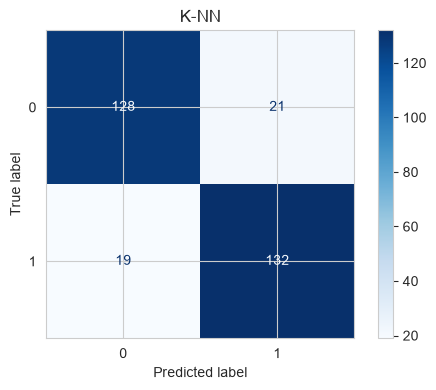

[[122  27]
 [ 26 125]]


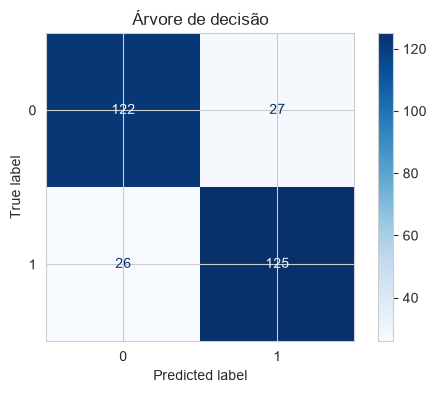

In [7]:
# Matriz de confusão do K-NN
matriz = confusion_matrix(y_test, y_pred_KNN)
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_KNN, 
    cmap=plt.cm.Blues
)
plt.title('K-NN')
plt.show()

# Matriz de confusão da árvore de decisão
matriz = confusion_matrix(y_test, y_pred_tree)
print(matriz)
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_tree, 
    cmap=plt.cm.Blues
)
plt.title('Árvore de decisão')
plt.show()

### Precisão (Precision) e Revocação (Recall)

**Precisão (Precision):** de todas as amostras que o modelo *previu* como
classe positiva, qual proporção realmente era da classe positiva? Responde à
pergunta: *"quando o modelo diz que é positivo, o quanto posso confiar nele?"*

$$
\text{Precisão} = \frac{VP}{VP + FP}
$$

**Revocação (Recall)**, também chamada de *sensibilidade*: de todas as amostras
que *realmente eram* da classe positiva, qual proporção o modelo conseguiu
identificar corretamente? Responde à pergunta: *"de tudo que era positivo,
quanto o modelo conseguiu capturar?"*

$$
\text{Recall} = \frac{VP}{VP + FN}
$$

**Existe um trade-off natural entre as duas.** Um modelo pode aumentar o
recall classificando quase tudo como positivo (mas perde precisão, pois gera
muitos falsos positivos); e pode aumentar a precisão sendo muito exigente para
classificar como positivo (mas perde recall, deixando passar casos positivos
verdadeiros como falsos negativos).

A escolha de qual métrica priorizar depende do problema: em diagnóstico de
doenças graves, geralmente priorizamos o **recall** (não podemos deixar passar
um caso positivo); já em filtros de spam, muitas vezes priorizamos a
**precisão** (não queremos bloquear e-mails legítimos por engano).

In [8]:
# Precisao
pr_KNN = precision_score(y_test, y_pred_KNN)
pr_tree = precision_score(y_test, y_pred_tree)
# Recall
recall_KNN = recall_score(y_test, y_pred_KNN)
recall_tree = recall_score(y_test, y_pred_tree)

print('K-NN:')
print('Precisão:', pr_KNN)
print('Recall:', recall_KNN)
print('\n')
print('Árvore de decisão:')
print('Precisão:', pr_tree)
print('Recall:', recall_tree)

K-NN:
Precisão: 0.8627450980392157
Recall: 0.8741721854304636


Árvore de decisão:
Precisão: 0.8223684210526315
Recall: 0.8278145695364238


### Especificidade

A **especificidade** é o "recall da classe negativa": de todas as amostras que *realmente eram* da classe negativa, qual proporção o modelo conseguiu identificar corretamente como negativas?

$$
\text{Especificidade} = \frac{VN}{VN + FP}
$$

Repare a simetria com o recall ($\frac{VP}{VP+FN}$): o recall mede o quanto o modelo acerta entre os positivos reais, e a especificidade mede o quanto o modelo acerta entre os negativos reais. Em diagnóstico médico, por exemplo, a especificidade responde: *"de todas as pessoas realmente saudáveis, quantas o exame corretamente identificou como saudáveis (sem gerar um alarme falso)?"*

O scikit-learn não tem uma função `specificity_score` pronta, mas podemos calculá-la facilmente com `recall_score`, invertendo qual classe é tratada como "positiva" (usando o argumento `pos_label=0`) -- afinal, a especificidade é *exatamente* o recall calculado em relação à classe 0 em vez da classe 1.


In [9]:
espec_KNN = recall_score(y_test, y_pred_KNN, pos_label=0)
espec_tree = recall_score(y_test, y_pred_tree, pos_label=0)
print(f"Especificidade - KNN: {espec_KNN:.4f}")
print(f"Especificidade - Árvore: {espec_tree:.4f}")

Especificidade - KNN: 0.8591
Especificidade - Árvore: 0.8188


### F1-score

O **F1-score** é a **média harmônica** entre precisão e recall. Ele
resume as duas métricas em um único número, sendo especialmente útil quando
queremos um equilíbrio entre elas (em vez de otimizar apenas uma, à custa da
outra).

$$
F_1 = 2 \times \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão} + \text{Recall}}
$$

**Por que média harmônica, e não a média aritmética simples?** A média
harmônica penaliza mais fortemente quando um dos dois valores (precisão ou
recall) é muito baixo. Por exemplo, um modelo com precisão = 1.0 e recall = 0.0
teria média aritmética de 0.5 (parecendo razoável), mas F1-score = 0 (refletindo
corretamente que o modelo é inútil, pois nunca identifica um positivo verdadeiro).

In [10]:
f1_KNN = f1_score(y_test, y_pred_KNN)
f1_tree = f1_score(y_test, y_pred_tree)
print(f"F1 - KNN: {f1_KNN:.4f}")
print(f"F1 - Árvore: {f1_tree:.4f}")

F1 - KNN: 0.8684
F1 - Árvore: 0.8251


O `classification_report` do scikit-learn resume precisão, recall e F1-score (por classe e no geral) de forma compacta:

In [11]:
print('======== K-NN =========')
print(classification_report(y_test, y_pred_KNN, target_names=['Classe 0', 'Classe 1']))
print('======== Árvore de decisão =========')
print(classification_report(y_test, y_pred_tree, target_names=['Classe 0', 'Classe 1']))

======== K-NN =========
              precision    recall  f1-score   support

    Classe 0       0.87      0.86      0.86       149
    Classe 1       0.86      0.87      0.87       151

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

======== Árvore de decisão =========
              precision    recall  f1-score   support

    Classe 0       0.82      0.82      0.82       149
    Classe 1       0.82      0.83      0.83       151

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



### Curva ROC e AUC

Diferentemente das métricas anteriores (que dependem de um limiar fixo
de decisão, geralmente 0.5), a **curva ROC** (*Receiver Operating
Characteristic*) mostra como o desempenho do modelo varia à medida que
**testamos diferentes limiares de decisão**, do mais permissivo ao mais
restritivo.

A curva plota, para cada limiar possível:

- **Eixo Y — Taxa de Verdadeiros Positivos (TPR)**: é o próprio **recall**.

$$
TPR = \frac{VP}{VP + FN}
$$

- **Eixo X — Taxa de Falsos Positivos (FPR)**:

$$
FPR = \frac{FP}{FP + VN}
$$

Um classificador aleatório (que "chuta" as classes) produz uma curva próxima
da diagonal (linha pontilhada no gráfico abaixo). Quanto mais a curva se
aproxima do canto superior esquerdo (TPR alto e FPR baixo simultaneamente),
melhor o modelo.

**AUC (Area Under the Curve)** resume a curva ROC em um único número: a área
sob a curva. Interpretação:
- AUC = 1.0 → classificador perfeito;
- AUC = 0.5 → equivalente a um "chute" aleatório;
- AUC < 0.5 → pior que aleatório (nesse caso, inverter as previsões o
  tornaria melhor que aleatório).

A AUC também pode ser interpretada como: *a probabilidade de o modelo atribuir
uma pontuação maior a uma amostra positiva escolhida ao acaso do que a uma
amostra negativa escolhida ao acaso.*

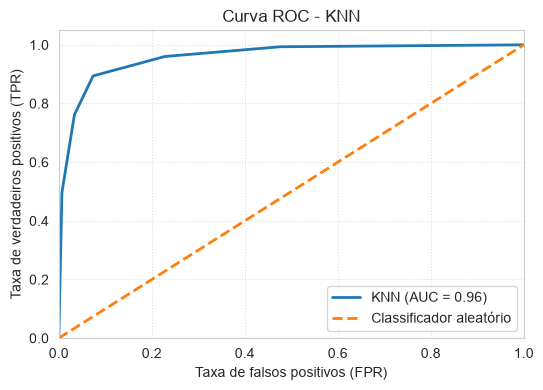

In [12]:
# Cria um classificador k-NN com k vizinhos.
knn = KNeighborsClassifier(n_neighbors=5)
# Treina o modelo usando os dados de treinamento.
knn.fit(X_train,y_train)

# Calcula, para cada exemplo do conjunto de teste, a probabilidade estimada de pertencer a cada classe.
# [:, 1] seleciona apenas a probabilidade da classe positiva, necessária para construir a curva ROC.
y_probs_KNN = knn.predict_proba(X_test)[:, 1]

# Calcula os pontos da curva ROC.
# fpr: taxa de falsos positivos;
# tpr: taxa de verdadeiros positivos;
# thresholds: diferentes limiares usados para transformar as probabilidades em decisões de classificação.
fpr, tpr, thresholds = roc_curve(y_test,y_probs_KNN)

# Calcula a área sob a curva ROC.
auc_score = roc_auc_score(y_test,y_probs_KNN)

# Cria a figura.
plt.figure(figsize=(6, 4))

# Desenha a curva ROC do modelo k-NN.
plt.plot(fpr,tpr,linewidth=2,label=f"KNN (AUC = {auc_score:.2f})")

# Desenha a linha de referência correspondente a um classificador aleatório.
plt.plot([0, 1],[0, 1],linewidth=2,linestyle="--",label="Classificador aleatório")

# Define os limites dos eixos.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Define os nomes dos eixos e o título.
plt.xlabel("Taxa de falsos positivos (FPR)")
plt.ylabel("Taxa de verdadeiros positivos (TPR)")
plt.title("Curva ROC - KNN")

# Mostra a legenda e a grade.
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

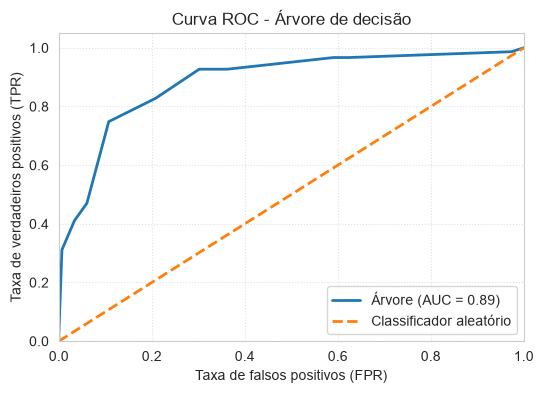

In [13]:
# Cria uma árvore de decisão.
tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=random_seed
)

# Treina a árvore usando os dados de treinamento.
tree.fit(X_train,y_train)

# Calcula, para cada exemplo do conjunto de teste, a probabilidade estimada de pertencer a cada classe.
# [:, 1] seleciona apenas a probabilidade da classe positiva, necessária para construir a curva ROC.
y_probs_tree = tree.predict_proba(X_test)[:, 1]

# Calcula os pontos da curva ROC.
# fpr: taxa de falsos positivos;
# tpr: taxa de verdadeiros positivos;
# thresholds: diferentes limiares usados para transformar as probabilidades em decisões de classificação.
fpr, tpr, thresholds = roc_curve(y_test,y_probs_tree)

# Calcula a área sob a curva ROC.
auc_score = roc_auc_score(y_test,y_probs_tree)

# Cria a figura.
plt.figure(figsize=(6, 4))

# Desenha a curva ROC do modelo k-NN.
plt.plot(fpr,tpr,linewidth=2,label=f"Árvore (AUC = {auc_score:.2f})")

# Desenha a linha de referência correspondente a um classificador aleatório.
plt.plot([0, 1],[0, 1],linewidth=2,linestyle="--",label="Classificador aleatório")

# Define os limites dos eixos.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Define os nomes dos eixos e o título.
plt.xlabel("Taxa de falsos positivos (FPR)")
plt.ylabel("Taxa de verdadeiros positivos (TPR)")
plt.title("Curva ROC - Árvore de decisão")

# Mostra a legenda e a grade.
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

Por que observar como o limiar varia? Por padrão, os modelos
classificam como "positivo" (classe 1) qualquer amostra com probabilidade
prevista maior que 0.5. Mas esse limiar pode ser ajustado: diminuí-lo aumenta
o recall (captura mais positivos), às custas da precisão; aumentá-lo faz o
oposto. A curva ROC (e a curva de precisão-recall, a seguir) tornam essa
troca visível e ajudam a escolher o limiar mais adequado ao problema.

## Curva Precisão-Recall

A **curva precisão-recall** é semelhante à curva ROC, mas plota diretamente **precisão vs. recall** para os diferentes limiares de decisão,
em vez de TPR vs. FPR.

Essa curva é especialmente útil em conjuntos de dados **desbalanceados**, pois, ao contrário da curva ROC, ela não é "otimista" quando a classe negativa é muito maior que a positiva (já que a FPR usada na ROC tem no denominador o total de negativos, que é grande, "diluindo" o efeito dos falsos positivos).

A métrica resumo equivalente à AUC, para essa curva, é a **Average Precision (AP)**: aproximadamente a área sob a curva precisão-recall.

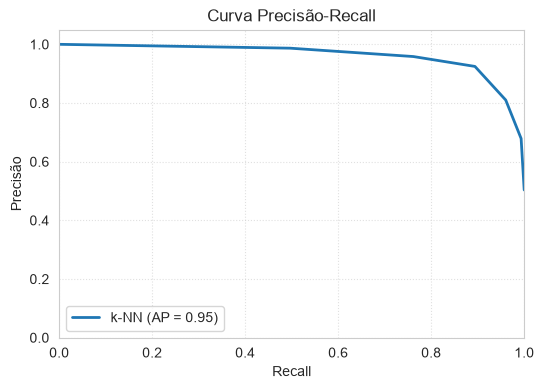

In [14]:
# Calcula, para cada exemplo do conjunto de teste,
# a probabilidade estimada de pertencer à classe positiva.
# [:, 1] seleciona a probabilidade da classe positiva.
y_probs_KNN = knn.predict_proba(X_test)[:, 1]

# Calcula os pontos da curva Precisão-Recall.
# precision: proporção das previsões positivas que estão corretas;
# recall: proporção dos exemplos positivos que foram identificados;
# thresholds: diferentes limiares utilizados para classificação.
precision, recall, thresholds = precision_recall_curve(y_test,y_probs_KNN)

# Calcula a Average Precision (AP)
ap_score = average_precision_score(y_test,y_probs_KNN)

# Cria a figura.
plt.figure(figsize=(6, 4))
# Desenha a curva Precisão-Recall do k-NN.
plt.plot(recall,precision,linewidth=2,label=f"k-NN (AP = {ap_score:.2f})")

# Define os limites dos eixos.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Define os nomes dos eixos e o título.
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precisão-Recall")

plt.legend(loc="lower left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

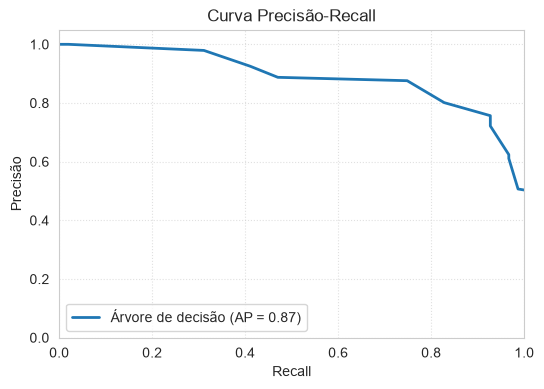

In [15]:
from sklearn.metrics import (precision_recall_curve,average_precision_score)

# Calcula, para cada exemplo do conjunto de teste,
# a probabilidade estimada de pertencer à classe positiva.
y_probs_tree = tree.predict_proba(X_test)[:, 1]

# Calcula os pontos da curva Precisão-Recall.
# precision: proporção das previsões positivas que estão corretas;
# recall: proporção dos exemplos positivos que foram identificados;
# thresholds: diferentes limiares utilizados para classificação.
precision, recall, thresholds = precision_recall_curve(y_test,y_probs_tree)

# Calcula a Average Precision (AP),
ap_score = average_precision_score(y_test,y_probs_tree)

# Cria a figura.
plt.figure(figsize=(6, 4))
# Desenha a curva Precisão-Recall da árvore.
plt.plot(recall,precision,linewidth=2,label=f"Árvore de decisão (AP = {ap_score:.2f})")

# Define os limites dos eixos.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Define os nomes dos eixos e o título.
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precisão-Recall")

plt.legend(loc="lower left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

## O efeito do desbalanceamento

Para ilustrar de forma prática a limitação da acurácia, vamos criar um novo conjunto de dados fortemente desbalanceado (apenas 5% de exemplos da classe positiva) e comparar um classificador real com um classificador "ingênuo" que sempre prevê a classe majoritária.

In [16]:
# Gera um conjunto de dados desbalanceado: 95% classe 0, 5% classe 1
X_desb, y_desb = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=5,
    weights=[0.95, 0.05],   # forte desbalanceamento
    class_sep=1.0,
    random_state=random_seed
)

print("Distribuição das classes no conjunto desbalanceado:")
print(pd.Series(y_desb).value_counts(normalize=True).round(3))

X_treino_d, X_teste_d, y_treino_d, y_teste_d = train_test_split(X_desb, y_desb, test_size=0.3, random_state=random_seed, stratify=y_desb)

# Escolha aqui o classificador
modelo_desb = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=random_seed )
#modelo_desb = KNeighborsClassifier(n_neighbors=5)

modelo_desb.fit(X_treino_d, y_treino_d)
y_pred_desb = modelo_desb.predict(X_teste_d)

# "Classificador ingenuo": sempre preve a classe majoritaria (0), ignorando os atributos
y_pred_ingenuo = np.zeros_like(y_teste_d) # Cria um vetor de zeros com o mesmo formato e tipo de dados de y_teste_d

print("\n===== Classificador Ingênuo (sempre prevê classe 0) =====")
print(f"Acurácia: {accuracy_score(y_teste_d, y_pred_ingenuo):.4f}")
print(f"Recall (classe 1):   {recall_score(y_teste_d, y_pred_ingenuo, zero_division=0):.4f}")
print(f"F1-score (classe 1): {f1_score(y_teste_d, y_pred_ingenuo, zero_division=0):.4f}")

print("\n===== Árvore de decisão (modelo real) =====")
print(f"Acurácia: {accuracy_score(y_teste_d, y_pred_desb):.4f}")
print(f"Recall (classe 1):   {recall_score(y_teste_d, y_pred_desb):.4f}")
print(f"F1-score (classe 1): {f1_score(y_teste_d, y_pred_desb):.4f}")

Distribuição das classes no conjunto desbalanceado:
0    0.946
1    0.054
Name: proportion, dtype: float64

===== Classificador Ingênuo (sempre prevê classe 0) =====
Acurácia: 0.9467
Recall (classe 1):   0.0000
F1-score (classe 1): 0.0000

===== Árvore de decisão (modelo real) =====
Acurácia: 0.9567
Recall (classe 1):   0.2500
F1-score (classe 1): 0.3810


Note que o classificador ingênuo, que nunca identifica corretamente um
único exemplo da classe 1, ainda assim atinge uma acurácia muito alta
(próxima da proporção da classe majoritária). No entanto, seu recall e F1-score
para a classe positiva são zero, revelando que ele é completamente inútil
para identificar a classe minoritária. Esse é o motivo pelo qual, em bases
desbalanceadas, é fundamental complementar a acurácia com métricas como
recall, F1-score e AUC.

Uma maneira simples de tratarmos o desbalanceamento é considerar uma árvore considerando `class_weight="balanced"`. O parâmetro `class_weight="balanced"` faz com que a árvore atribua pesos maiores às classes minoritárias durante o treinamento.

In [17]:
# Classificação usando um classificador
modelo_desb = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,class_weight="balanced", random_state=random_seed )
modelo_desb.fit(X_treino_d, y_treino_d)
y_pred_desb = modelo_desb.predict(X_teste_d)

# "Classificador ingenuo": sempre preve a classe majoritaria (0), ignorando os atributos
y_pred_ingenuo = np.zeros_like(y_teste_d)

print("\n===== Classificador Ingênuo (sempre prevê classe 0) =====")
print(f"Acurácia: {accuracy_score(y_teste_d, y_pred_ingenuo):.4f}")
print(f"Recall (classe 1):   {recall_score(y_teste_d, y_pred_ingenuo, zero_division=0):.4f}")
print(f"F1-score (classe 1): {f1_score(y_teste_d, y_pred_ingenuo, zero_division=0):.4f}")

print("\n===== Árvore de decisão (modelo real) =====")
print(f"Acurácia: {accuracy_score(y_teste_d, y_pred_desb):.4f}")
print(f"Recall (classe 1):   {recall_score(y_teste_d, y_pred_desb):.4f}")
print(f"F1-score (classe 1): {f1_score(y_teste_d, y_pred_desb):.4f}")


===== Classificador Ingênuo (sempre prevê classe 0) =====
Acurácia: 0.9467
Recall (classe 1):   0.0000
F1-score (classe 1): 0.0000

===== Árvore de decisão (modelo real) =====
Acurácia: 0.8683
Recall (classe 1):   0.7188
F1-score (classe 1): 0.3680


# Regressão

Enquanto a classificação prevê uma categoria, a regressão prevê um valor numérico contínuo.

Vamos gerar um conjunto de dados sintético não linear (com uma única variável de entrada, para facilitar a visualização), o que nos permitirá comparar visualmente como cada modelo se ajusta aos dados — inclusive mostrando os efeitos de subajuste (underfitting) e sobreajuste (overfitting).

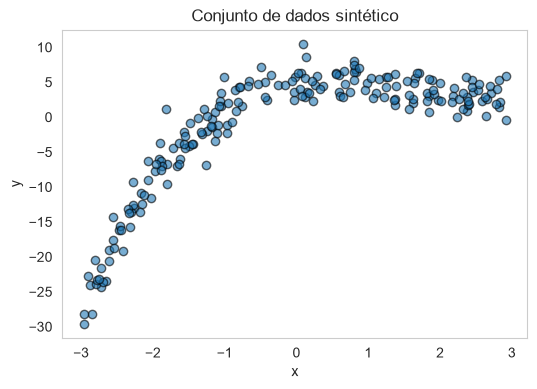

In [18]:
# Fixamos a semente aleatoria para reprodutibilidade
np.random.seed(random_seed)

# Geramos 200 valores de x, uniformemente distribuidos entre -3 e 3
n_amostras = 200
x = np.random.uniform(-3, 3, n_amostras)

# Definimos uma relacao NAO LINEAR verdadeira entre x e y (um polinomio cubico)
# e adicionamos ruido aleatorio (gaussiano), como acontece em dados do mundo real
ruido = np.random.normal(0, 2, n_amostras)
y_reg = 0.5 * x**3 - 2 * x**2 + x + 5 + ruido

# X precisa ser uma matriz 2D (n_amostras, n_atributos) para o scikit-learn, mesmo com 1 atributo so
X_reg = x.reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(x, y_reg, alpha=0.6, edgecolor='k')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Conjunto de dados sintético')
plt.grid(False)
plt.show()

Separando o treinamento e teste.

In [19]:
# Mesma logica do split usado na classificacao (sem 'stratify', que nao se aplica a regressao).
X_treino_r, X_teste_r, y_treino_r, y_teste_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=random_seed)
print("Tamanho do treino:", X_treino_r.shape)
print("Tamanho do teste: ", X_teste_r.shape)

Tamanho do treino: (160, 1)
Tamanho do teste:  (40, 1)


Vamos treinar três modelos:

- **Regressão Linear**: ajusta uma única reta aos dados — como a relação
  real é não linear (cúbica), esperamos que esse modelo **subajuste**
  (*underfitting*) os dados;
- **Regressão Polinomial**: estende a regressão linear adicionando potências
  do atributo original ($x^2$, $x^3$, ...) como novos atributos. Vamos testar
  alguns graus diferentes para observar o equilíbrio entre subajuste e
  sobreajuste;
- **Knn para regressão**: em vez de prever a classe majoritária entre os
  vizinhos (como na classificação), prevê a **média** do valor de $y$ entre
  os $k$ vizinhos mais próximos.

In [20]:
# ----- Regressao Linear simples -----
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino_r, y_treino_r)

# ----- Regressao Polinomial -----
# PolynomialFeatures transforma o atributo original x em [x, x^2, ..., x^grau]
# Testamos alguns graus diferentes, para ilustrar o efeito da complexidade do modelo
graus_polinomiais = [3, 5, 15]
modelos_poly = {}
transformadores_poly = {}

for grau in graus_polinomiais:
    poly = PolynomialFeatures(degree=grau, include_bias=False)
    X_treino_poly = poly.fit_transform(X_treino_r)

    modelo_poly = LinearRegression()
    modelo_poly.fit(X_treino_poly, y_treino_r)

    transformadores_poly[grau] = poly
    modelos_poly[grau] = modelo_poly

# ----- KNN para regressao -----
modelo_knn_reg = KNeighborsRegressor(n_neighbors=5)
modelo_knn_reg.fit(X_treino_r, y_treino_r)

print("Modelos de regressão treinados com sucesso.")
print(f"Graus polinomiais testados: {graus_polinomiais}")

Modelos de regressão treinados com sucesso.
Graus polinomiais testados: [3, 5, 15]


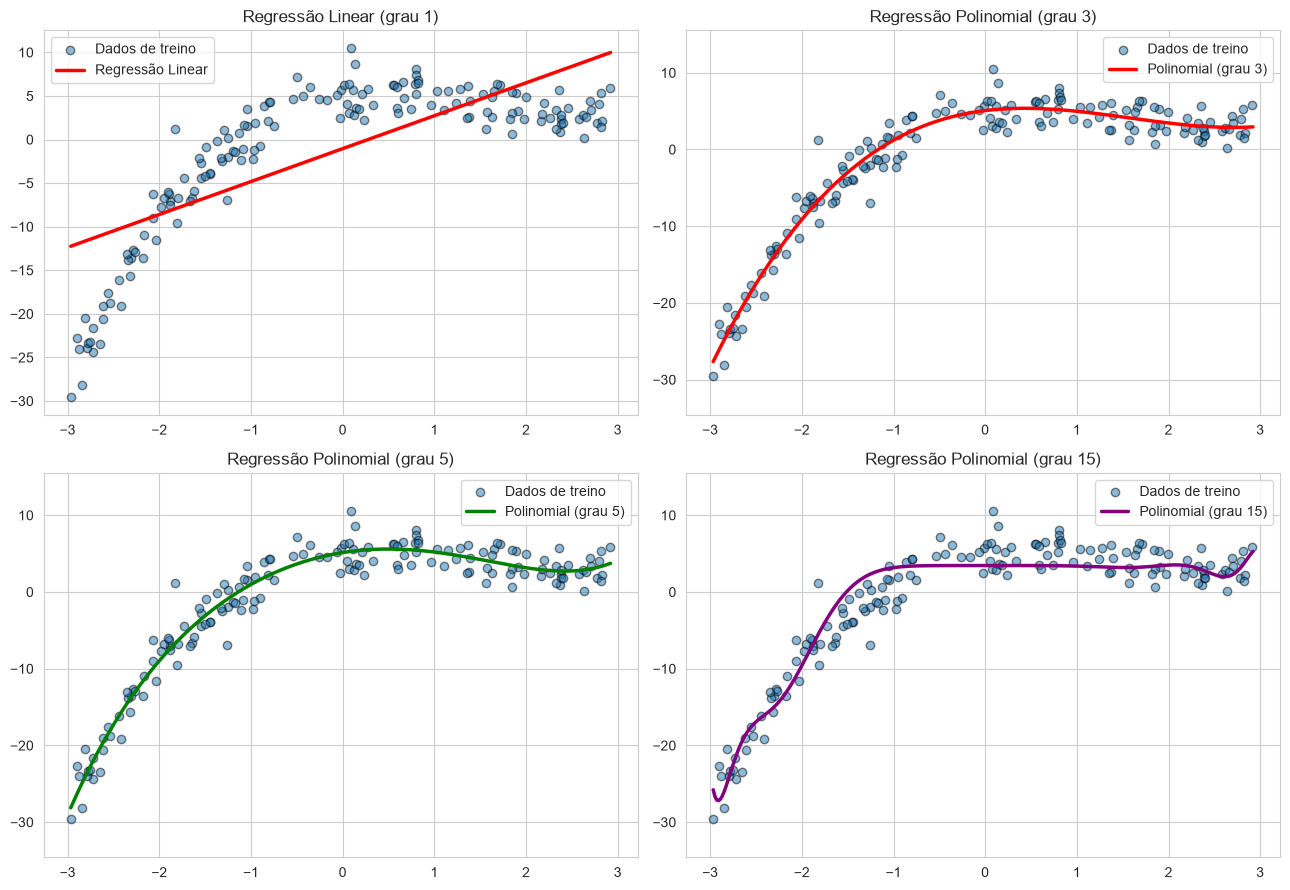

In [21]:
# Criamos uma grade fina de valores de x, apenas para desenhar as curvas de forma suave
x_grade = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
# ----- Regressao Linear -----
axes[0].scatter(X_treino_r, y_treino_r, alpha=0.5, edgecolor='k', label='Dados de treino')
axes[0].plot(x_grade, modelo_linear.predict(x_grade), color='red', linewidth=2.5, label='Regressão Linear')
axes[0].set_title('Regressão Linear (grau 1)')
axes[0].legend()

# ----- Regressao Polinomial
cores_poly = {3: 'red', 5: 'green', 15: 'purple'}
for i, grau in enumerate(graus_polinomiais):
    ax = axes[i + 1]
    ax.scatter(X_treino_r, y_treino_r, alpha=0.5, edgecolor='k', label='Dados de treino')

    x_grade_poly = transformadores_poly[grau].transform(x_grade)
    y_grade_pred = modelos_poly[grau].predict(x_grade_poly)

    ax.plot(x_grade, y_grade_pred, color=cores_poly[grau], linewidth=2.5, label=f'Polinomial (grau {grau})')
    ax.set_ylim(y_reg.min() - 5, y_reg.max() + 5)  # limita o eixo Y para nao distorcer a visualizacao com o overfitting
    ax.set_title(f'Regressão Polinomial (grau {grau})')
    ax.legend()

plt.tight_layout()
plt.show()

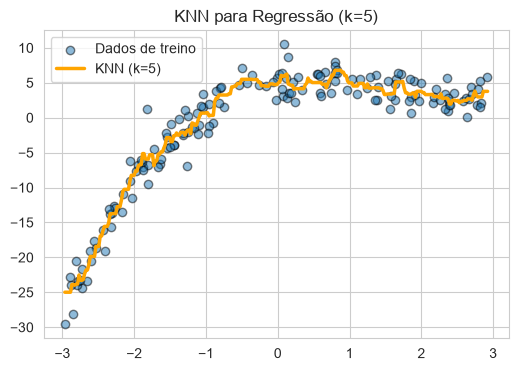

In [22]:
# Visualizacao separada para o KNN, ja que ele nao produz uma curva suave e continua como os modelos anteriores
fig, ax = plt.subplots()
ax.scatter(X_treino_r, y_treino_r, alpha=0.5, edgecolor='k', label='Dados de treino')
ax.plot(x_grade, modelo_knn_reg.predict(x_grade), color='orange', linewidth=2.5, label='KNN (k=5)')
ax.set_title('KNN para Regressão (k=5)')
ax.legend()
plt.show()

Antes de calcular as métricas, vamos gerar as previsões de todos os modelos (regressão linear, os três graus polinomiais e o KNN) no conjunto de teste, que não foi usado no treinamento:

In [23]:
previsoes_reg = {}

# Regressao Linear
previsoes_reg['Linear'] = modelo_linear.predict(X_teste_r)

# Regressao Polinomial (para cada grau testado)
for grau in graus_polinomiais:
    X_teste_poly = transformadores_poly[grau].transform(X_teste_r)
    previsoes_reg[f'Polinomial (grau {grau})'] = modelos_poly[grau].predict(X_teste_poly)

# KNN
previsoes_reg['KNN (k=5)'] = modelo_knn_reg.predict(X_teste_r)

print("Modelos com previsões geradas:", list(previsoes_reg.keys()))

Modelos com previsões geradas: ['Linear', 'Polinomial (grau 3)', 'Polinomial (grau 5)', 'Polinomial (grau 15)', 'KNN (k=5)']


O MAE (Mean Absolute Error) calcula a média das diferenças
absolutas entre os valores previstos ($\hat{y}_i$) e os valores reais ($y_i$):

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

O MAE está na mesma unidade da variável alvo, e representa, em média, "o quanto o modelo erra" em valor absoluto. É uma
métrica robusta a outliers (valores atípicos), pois não eleva os erros ao
quadrado — um erro grande contribui proporcionalmente, sem ser amplificado.

In [24]:
mae_resultados = {}
for nome, y_pred in previsoes_reg.items():
    mae_resultados[nome] = mean_absolute_error(y_teste_r, y_pred)
    print(f"MAE - {nome}: {mae_resultados[nome]:.4f}")

# Verificacao manual da formula do MAE, para o modelo linear
mae_manual = np.mean(np.abs(y_teste_r - previsoes_reg['Linear']))
print(f"\nMAE (Linear) calculado manualmente: {mae_manual:.4f}")
print(f"MAE (Linear) via mean_absolute_error: {mae_resultados['Linear']:.4f}")

MAE - Linear: 4.7362
MAE - Polinomial (grau 3): 1.7101
MAE - Polinomial (grau 5): 1.7317
MAE - Polinomial (grau 15): 1.9628
MAE - KNN (k=5): 1.8841

MAE (Linear) calculado manualmente: 4.7362
MAE (Linear) via mean_absolute_error: 4.7362


O MSE (Mean Squared Error) calcula a média dos quadrados das
diferenças entre valores previstos e reais:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Como os erros são elevados ao quadrado, o MSE penaliza mais fortemente
erros grandes (outliers) do que o MAE — um erro duas vezes maior contribui
quatro vezes mais para o MSE. Além disso, o MSE fica em uma unidade "ao
quadrado" em relação à variável alvo (ex.: se `y` é medido em reais, o MSE é
medido em "reais ao quadrado"), o que dificulta sua interpretação direta.

Por isso, é comum calcular o RMSE (Root Mean Squared Error), que é
simplesmente a raiz quadrada do MSE, trazendo o valor de volta à mesma unidade
da variável alvo — o que facilita bastante a interpretação:

$$
RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

In [25]:
mse_resultados = {}
rmse_resultados = {}

for nome, y_pred in previsoes_reg.items():
    mse_resultados[nome] = mean_squared_error(y_teste_r, y_pred)
    rmse_resultados[nome] = np.sqrt(mse_resultados[nome])   # RMSE = raiz quadrada do MSE
    print(f"{nome:22s} | MSE: {mse_resultados[nome]:8.4f} | RMSE: {rmse_resultados[nome]:.4f}")

Linear                 | MSE:  33.0856 | RMSE: 5.7520
Polinomial (grau 3)    | MSE:   4.4143 | RMSE: 2.1010
Polinomial (grau 5)    | MSE:   4.5584 | RMSE: 2.1350
Polinomial (grau 15)   | MSE:   6.0812 | RMSE: 2.4660
KNN (k=5)              | MSE:   5.3127 | RMSE: 2.3049


Para ilustrar por que o MSE/RMSE é mais sensível a erros grandes do que o MAE, vamos comparar as duas métricas em um pequeno exemplo com e sem um valor atípico:

In [26]:
# Exemplo: 5 valores reais e previstos, SEM outlier
y_real_exemplo = np.array([10, 12, 9, 11, 10])
y_pred_exemplo = np.array([11, 11, 10, 10, 9])

mae_exemplo = mean_absolute_error(y_real_exemplo, y_pred_exemplo)
rmse_exemplo = np.sqrt(mean_squared_error(y_real_exemplo, y_pred_exemplo))
print(f"Sem outlier    -> MAE: {mae_exemplo:.3f} | RMSE: {rmse_exemplo:.3f}")

# Mesmo exemplo, mas agora com UM erro grande (outlier) na ultima previsao
y_pred_exemplo_outlier = np.array([11, 11, 10, 10, 20])  # a ultima previsao errou por 10 unidades

mae_outlier = mean_absolute_error(y_real_exemplo, y_pred_exemplo_outlier)
rmse_outlier = np.sqrt(mean_squared_error(y_real_exemplo, y_pred_exemplo_outlier))
print(f"Com outlier    -> MAE: {mae_outlier:.3f} | RMSE: {rmse_outlier:.3f}")

Sem outlier    -> MAE: 1.000 | RMSE: 1.000
Com outlier    -> MAE: 2.800 | RMSE: 4.561


Note que o RMSE aumentou proporcionalmente muito mais do que o MAE diante de um unico erro grande - isso ilustra sua maior sensibilidade a outliers.

O R² (coeficiente de determinação) mede a proporção da variância da
variável alvo que é explicada pelo modelo, em comparação com um modelo
trivial que sempre prevê a média de $y$:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

onde $\bar{y}$ é a média dos valores reais de $y$.

Interpretação:
- $R^2 = 1$: o modelo explica perfeitamente a variabilidade dos dados (ajuste perfeito);
- $R^2 = 0$: o modelo é tão bom quanto simplesmente prever a média de $y$ para todas as amostras;
- $R^2 < 0$: o modelo é pior do que prever a média (pode acontecer em modelos muito ruins ou mal ajustados no conjunto de teste).

Limitação do R²: ele nunca diminui quando adicionamos mais atributos
(ou aumentamos o grau do polinômio) ao modelo, mesmo que esses atributos não
tenham relação real com o problema — isso pode mascarar o sobreajuste
(overfitting). É exatamente esse problema que o R² ajustado corrige.

In [27]:
r2_resultados = {}
for nome, y_pred in previsoes_reg.items():
    r2_resultados[nome] = r2_score(y_teste_r, y_pred)
    print(f"R² - {nome}: {r2_resultados[nome]:.4f}")

# Verificacao manual da formula do R², para o modelo linear
y_medio = np.mean(y_teste_r)
soma_residuos_quadrados = np.sum((y_teste_r - previsoes_reg['Linear'])**2)
soma_total_quadrados = np.sum((y_teste_r - y_medio)**2)
r2_manual = 1 - (soma_residuos_quadrados / soma_total_quadrados)

print(f"\nR² (Linear) calculado manualmente: {r2_manual:.4f}")
print(f"R² (Linear) via r2_score:            {r2_resultados['Linear']:.4f}")

R² - Linear: 0.5307
R² - Polinomial (grau 3): 0.9374
R² - Polinomial (grau 5): 0.9353
R² - Polinomial (grau 15): 0.9137
R² - KNN (k=5): 0.9246

R² (Linear) calculado manualmente: 0.5307
R² (Linear) via r2_score:            0.5307


O R² ajustado introduz uma penalização pelo número de atributos ($p$)
usados no modelo, em relação ao número de amostras ($n$):

$$
R^2_{ajustado} = 1 - (1 - R^2) \times \frac{n - 1}{n - p - 1}
$$

Diferente do R² comum, o R² ajustado pode diminuir quando adicionamos um
atributo (ou aumentamos o grau polinomial) que não contribui de fato para
explicar a variável alvo — tornando-o mais adequado para comparar modelos
com números diferentes de atributos, como é exatamente o nosso caso ao
comparar os diferentes graus polinomiais.

In [28]:
def r2_ajustado(r2, n_amostras, n_atributos):
    """
    Calcula o R² ajustado.

    Parametros
    ----------
    r2 : float
        Valor do R² comum.
    n_amostras : int
        Numero de amostras (observacoes) usadas na avaliacao.
    n_atributos : int
        Numero de atributos (variaveis preditoras) usados pelo modelo.
    """
    return 1 - (1 - r2) * (n_amostras - 1) / (n_amostras - n_atributos - 1)

n_teste = len(y_teste_r)

# Numero de atributos de cada modelo:
# - Linear e KNN usam apenas 1 atributo (x)
# - Polinomial de grau k usa k atributos (x, x^2, ..., x^k)
n_atributos_por_modelo = {
    'Linear': 1,
    'Polinomial (grau 3)': 3,
    'Polinomial (grau 5)': 5,
    'Polinomial (grau 15)': 15,
    'KNN (k=5)': 1
}

r2_ajustado_resultados = {}
for nome in previsoes_reg:
    p = n_atributos_por_modelo[nome]
    r2_ajustado_resultados[nome] = r2_ajustado(r2_resultados[nome], n_teste, p)
    print(f"{nome:22s} | Nº atributos: {p:2d} | R²: {r2_resultados[nome]:.4f} | R² ajustado: {r2_ajustado_resultados[nome]:.4f}")

Linear                 | Nº atributos:  1 | R²: 0.5307 | R² ajustado: 0.5183
Polinomial (grau 3)    | Nº atributos:  3 | R²: 0.9374 | R² ajustado: 0.9322
Polinomial (grau 5)    | Nº atributos:  5 | R²: 0.9353 | R² ajustado: 0.9258
Polinomial (grau 15)   | Nº atributos: 15 | R²: 0.9137 | R² ajustado: 0.8598
KNN (k=5)              | Nº atributos:  1 | R²: 0.9246 | R² ajustado: 0.9227


Os resíduos (diferença entre valor real e valor previsto, $y_i - \hat{y}_i$) são muito úteis para diagnosticar problemas no modelo. Idealmente, os resíduos
devem estar distribuídos aleatoriamente em torno de zero, sem nenhum padrão visível — um padrão sistemático nos resíduos (como uma curva) indica que o
modelo não está capturando toda a estrutura presente nos dados (por exemplo, subajuste em um modelo linear aplicado a uma relação não linear).

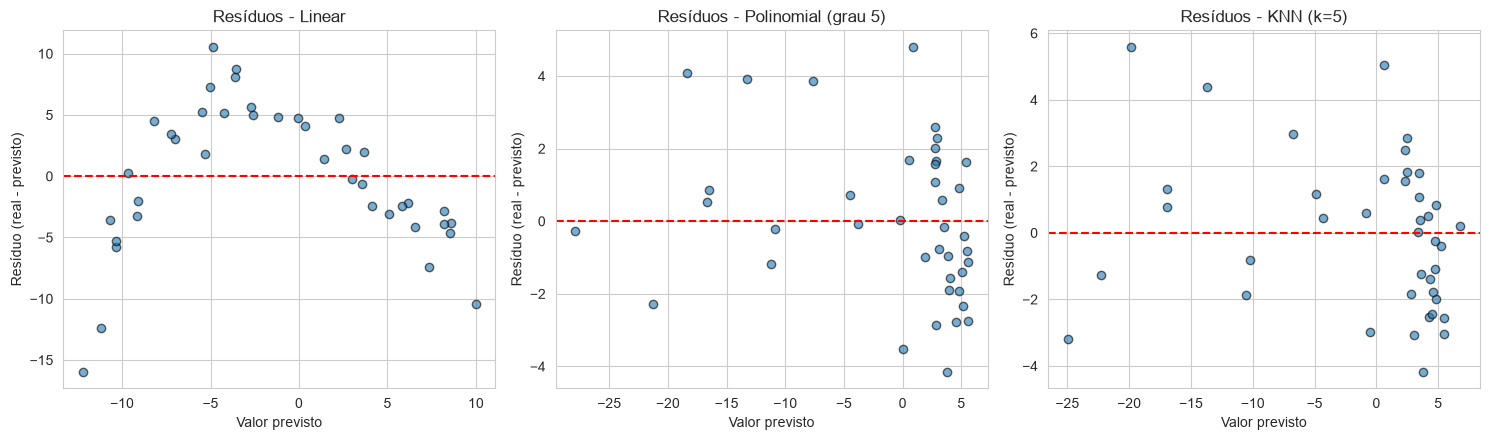

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Comparamos os residuos de 3 modelos representativos: o que mais subajusta (Linear),
# um bom equilibrio (Polinomial grau 5) e uma alternativa nao-parametrica (KNN).
modelos_para_residuos = {
    'Linear': previsoes_reg['Linear'],
    'Polinomial (grau 5)': previsoes_reg['Polinomial (grau 5)'],
    'KNN (k=5)': previsoes_reg['KNN (k=5)']
}

for ax, (nome, y_pred) in zip(axes, modelos_para_residuos.items()):
    residuos = y_teste_r - y_pred
    ax.scatter(y_pred, residuos, alpha=0.6, edgecolor='k')
    ax.axhline(y=0, color='red', linestyle='--')  # referencia: residuo zero (previsao perfeita)
    ax.set_xlabel('Valor previsto')
    ax.set_ylabel('Resíduo (real - previsto)')
    ax.set_title(f'Resíduos - {nome}')

plt.tight_layout()
plt.show()

Note como os resíduos da Regressão Linear apresentam um padrão de
curva (não estão distribuídos aleatoriamente em torno de zero), evidenciando
que o modelo linear não captura a relação cúbica presente nos dados, o que é um sinal
claro de subajuste. Já os modelos Polinomial (grau 5) e KNN
apresentam resíduos mais próximos de um padrão aleatório, indicando um ajuste
mais adequado.

O $R^2$ nunca diminui quando são adicionados novos atributos, mesmo que estes sejam inúteis. Por outro lado, o $R^2$ ajustado tem em conta os atributos irrelevantes, pelo que pode não aumentar com o número de atributos. Vamos verificar isso na prática.

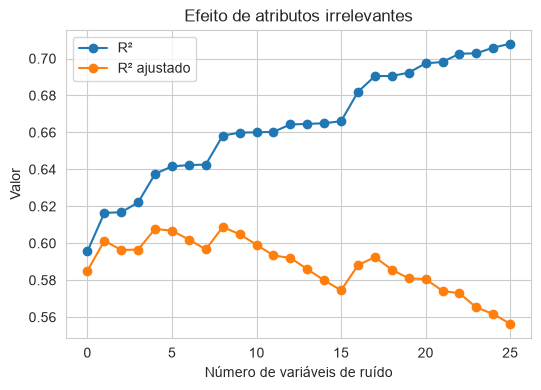

In [30]:
# Cria um gerador de números aleatórios.
rng = np.random.default_rng(10)
n = 80 # Número de observações da base simulada.
max_noise = 25 # Número máximo de atributos de ruído que serão adicionados.

# Gera dois atributos que terão relação com a variável resposta y.
X_informative = rng.normal(size=(n, 2))

# Define os coeficientes verdadeiros associados aos dois atributos.
# A relação verdadeira será aproximadamente: y = 2*X1 - X2 + ruído
beta = np.array([2.0,-1.0])

# Gera a variável resposta.
# X_informative @ beta calcula a combinação linear dos atributos.
# Depois adicionamos um ruído aleatório para tornar o problema mais próximo de uma situação real.
y_sim = (X_informative @ beta+ rng.normal(scale=1.5,size=n))

# Gera 25 atributos completamente aleatórios.
# Esses atributos não possuem relação verdadeira com y e serão usados apenas 
# para estudar o efeito da inclusão de variáveis irrelevantes no modelo.
X_noise = rng.normal(size=(n, max_noise))

# Lista onde serão armazenados os resultados para cada quantidade de atributos de ruído.
rows = []

# Ajuste dos modelos
# Repete o experimento adicionando progressivamente de 0 até 25 atributos de ruído ao modelo.
for number_noise in range(max_noise + 1):
    # Quando number_noise = 0, utilizamos apenas os dois atributos realmente informativos.
    if number_noise == 0:
        X_current = X_informative

    else:
        # Adiciona progressivamente atributos de ruído aos dois atributos informativos.
        X_current = np.hstack([X_informative,X_noise[:, :number_noise]])

    # Ajusta uma regressão linear utilizando todos os atributos disponíveis neste momento.
    current_model = LinearRegression().fit(X_current, y_sim)

    # Calcula o R² nos próprios dados utilizados para ajustar o modelo.
    current_r2 = current_model.score(X_current,y_sim)

    # Número total de atributos utilizados no modelo.
    p = X_current.shape[1]

    # Calcula o R² ajustado.
    # Diferentemente do R² tradicional, o R² ajustado penaliza a inclusão de novos atributos.
    adjusted_r2 = (1- (1 - current_r2)* (n - 1)/ (n - p - 1))

    # Armazena os resultados desta iteração.
    rows.append({
        "Variáveis de ruído": number_noise,
        "R²": current_r2,
        "R² ajustado": adjusted_r2
    })

# Converte os resultados em um DataFrame.
r2_comparison = pd.DataFrame(rows)

# Visualização dos resultados
plt.figure(figsize=(6, 4))

# Mostra como o R² varia à medida que adicionamos
# atributos sem relação verdadeira com y.
plt.plot(
    r2_comparison["Variáveis de ruído"],
    r2_comparison["R²"],
    marker="o",
    label="R²"
)

# Mostra o comportamento do R² ajustado,
# que penaliza modelos com muitos atributos.
plt.plot(
    r2_comparison["Variáveis de ruído"],
    r2_comparison["R² ajustado"],
    marker="o",
    label="R² ajustado"
)

plt.xlabel("Número de variáveis de ruído")
plt.ylabel("Valor")
plt.title("Efeito de atributos irrelevantes")
plt.legend()
plt.show()

Notem que um valor maior de $R^2$ não significa necessariamente que o modelo seja melhor. O valor de $R^2$ pode aumentar simplesmente porque adicionamos mais variáveis ao modelo, mesmo que elas sejam irrelevantes. Já o $R^2$ ajustado tenta corrigir esse problema penalizando modelos excessivamente complexos.

# Exercícios de fixação

1 - Faça a classificação da base abaixo e calcule as medidas que estudamos nesse notebook. Mostre também a curva ROC.

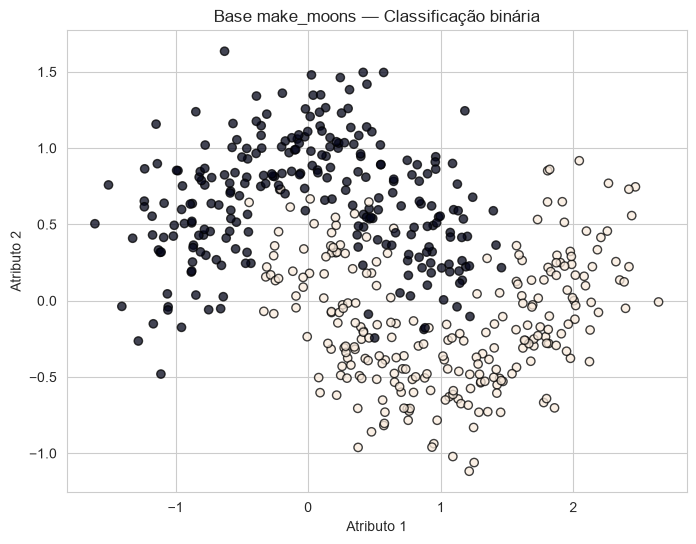

In [31]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500,noise=0.25,random_state=42)

dados = pd.DataFrame({
    "Atributo 1": X[:, 0],
    "Atributo 2": X[:, 1],
    "Classe": y
})

plt.figure(figsize=(8, 6))

# Mostra os pontos, utilizando uma cor para cada classe.
plt.scatter(
    dados["Atributo 1"],
    dados["Atributo 2"],
    c=dados["Classe"],
    alpha=0.75,
    edgecolor="black"
)

plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Base make_moons — Classificação binária")
plt.show()

2 - Faça a regressão da base abaixo e calcule as medidas que estudamos nesse notebook (MAE, MSE, RMSE, $R^2$ e $R^2$ ajustado). Compare pelo menos dois modelos (por exemplo, Regressão Linear e KNN, ou diferentes graus de um polinômio) e discuta qual deles apresenta os resíduos com padrão mais próximo do aleatório.


In [32]:
from sklearn.datasets import make_regression

# n_informative=3 (de um total de 5 atributos) significa que apenas 3 atributos realmente
# influenciam y -- os outros 2 sao "ruido", uteis para observar o efeito do R² ajustado.
X_ex2, y_ex2 = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=3,
    noise=15,
    random_state=42
)

print("Dimensões dos dados:", X_ex2.shape)

Dimensões dos dados: (300, 5)
